In [1]:
import sys
sys.path.append("../")

import pandas as pd

from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, create_monthly_sales
from src.visualization import plot_monthly_sales, plot_bar_chart, plot_horizontal_bar_chart

In [2]:
df = load_raw_data("../data/raw/train.csv")
clean_df = clean_raw_data(df)
clean_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Delivery Days
0,7981,CA-2015-103800,2015-01-03,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,4
1,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,4
2,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,4
3,740,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,4
4,1760,CA-2015-141817,2015-01-05,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,7


In [3]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9800 non-null   object        
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [4]:
clean_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Delivery Days    0
dtype: int64

In [5]:
clean_df.to_csv("../data/processed/clean_sales_data.csv", index=False)

## Tạo doanh số theo tháng

In [6]:
monthly_sales = create_monthly_sales(clean_df)
monthly_sales.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [7]:
monthly_sales.to_csv("../data/processed/monthly_sales.csv", index=False)

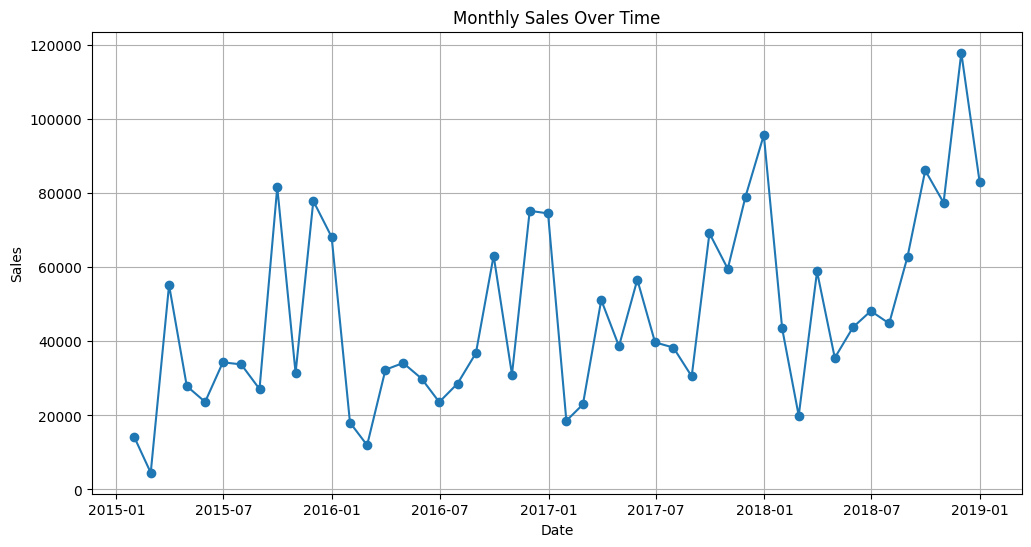

In [8]:
plot_monthly_sales(monthly_sales, save_path="../reports/figures/monthly_sales.png")

## Doanh số theo năm

In [9]:
clean_df["year"] = clean_df["Order Date"].dt.year
yearly_sales = clean_df.groupby("year")["Sales"].sum()
yearly_sales

year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

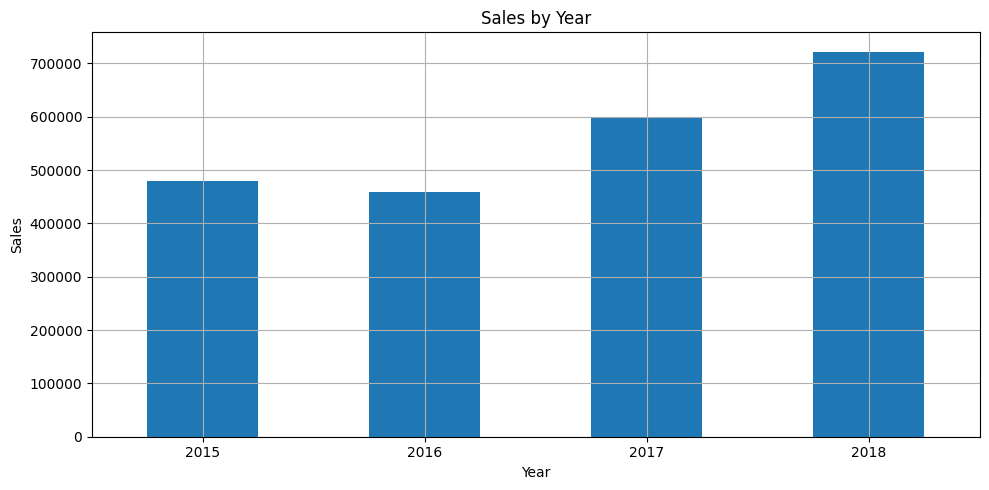

In [10]:
plot_bar_chart(yearly_sales, "Sales by Year", "Year", "Sales", "../reports/figures/sales_by_year.png")

## Doanh số theo tháng trong năm

In [11]:
clean_df["month"] = clean_df["Order Date"].dt.month
sales_by_month = clean_df.groupby("month")["Sales"].sum()
sales_by_month

month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64

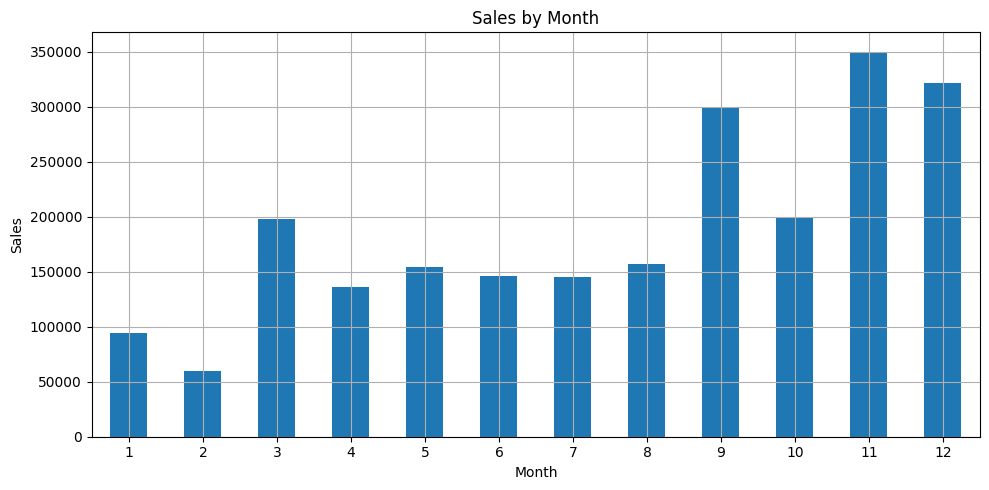

In [12]:
plot_bar_chart(sales_by_month, "Sales by Month", "Month", "Sales", "../reports/figures/sales_by_month.png")

## Doanh số theo Category

In [13]:
category_sales = clean_df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

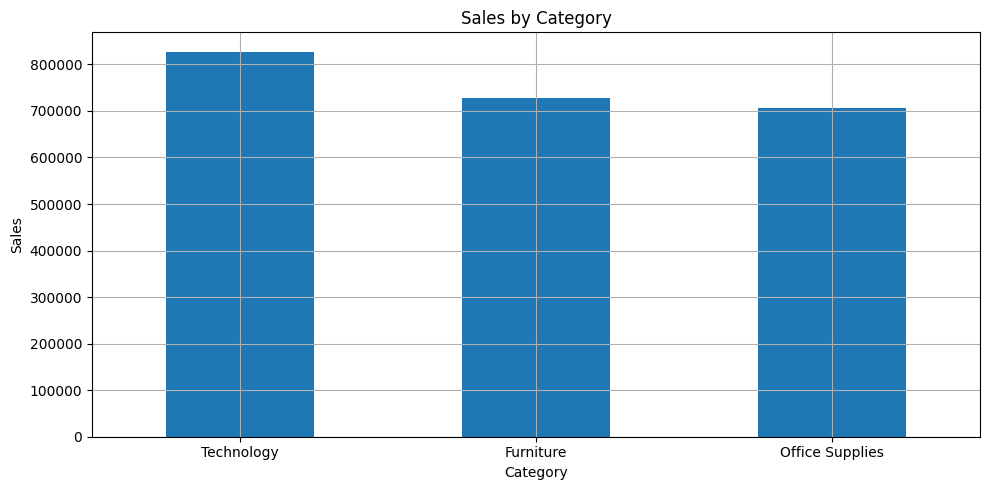

In [14]:
plot_bar_chart(category_sales, "Sales by Category", "Category", "Sales", "../reports/figures/sales_by_category.png")

## Doanh số theo Region

In [15]:
region_sales = clean_df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

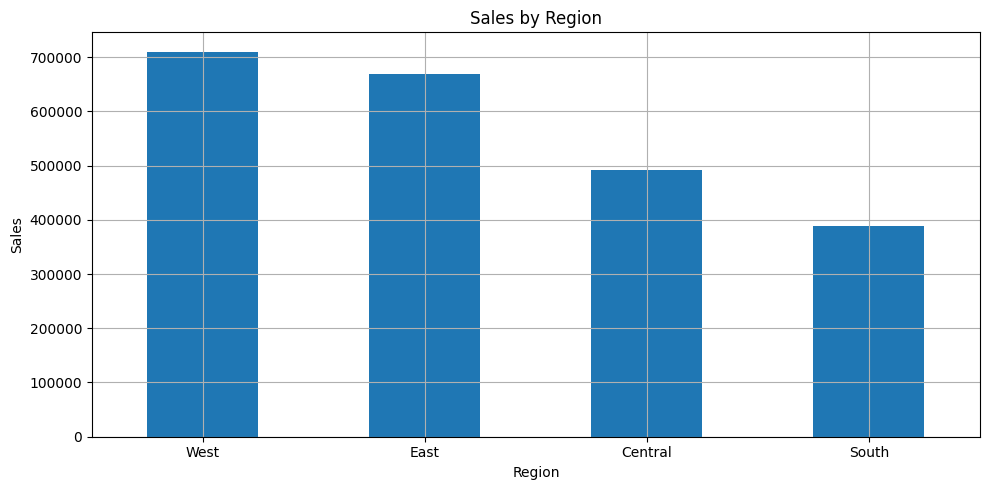

In [16]:
plot_bar_chart(region_sales, "Sales by Region", "Region", "Sales", "../reports/figures/sales_by_region.png")

## Doanh số theo Segment

In [17]:
segment_sales = clean_df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

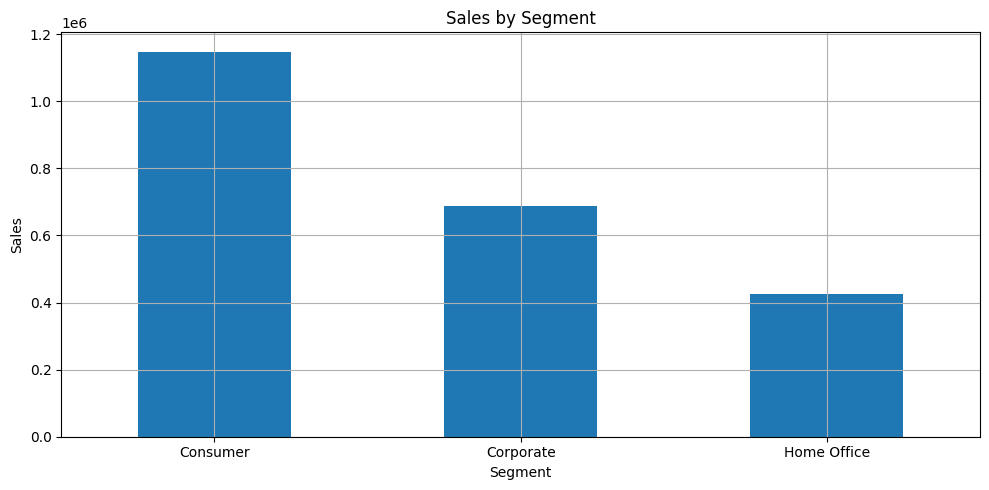

In [18]:
plot_bar_chart(segment_sales, "Sales by Segment", "Segment", "Sales", "../reports/figures/sales_by_segment.png")

## Doanh số theo Ship Mode

In [19]:
ship_mode_sales = clean_df.groupby("Ship Mode")["Sales"].sum().sort_values(ascending=False)
ship_mode_sales

Ship Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64

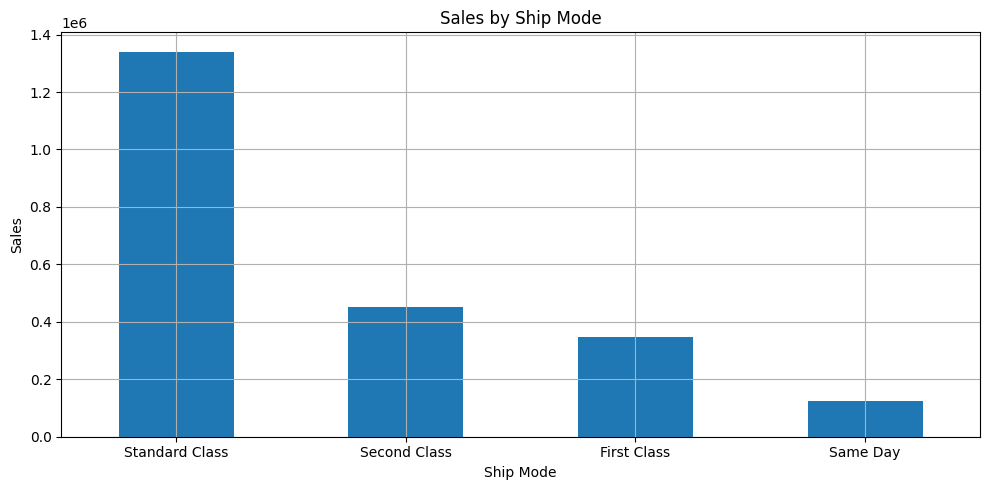

In [20]:
plot_bar_chart(ship_mode_sales, "Sales by Ship Mode", "Ship Mode", "Sales", "../reports/figures/sales_by_ship_mode.png")

## Top 10 Sub-Category theo doanh số

In [21]:
top_subcategory_sales = clean_df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
top_subcategory_sales

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

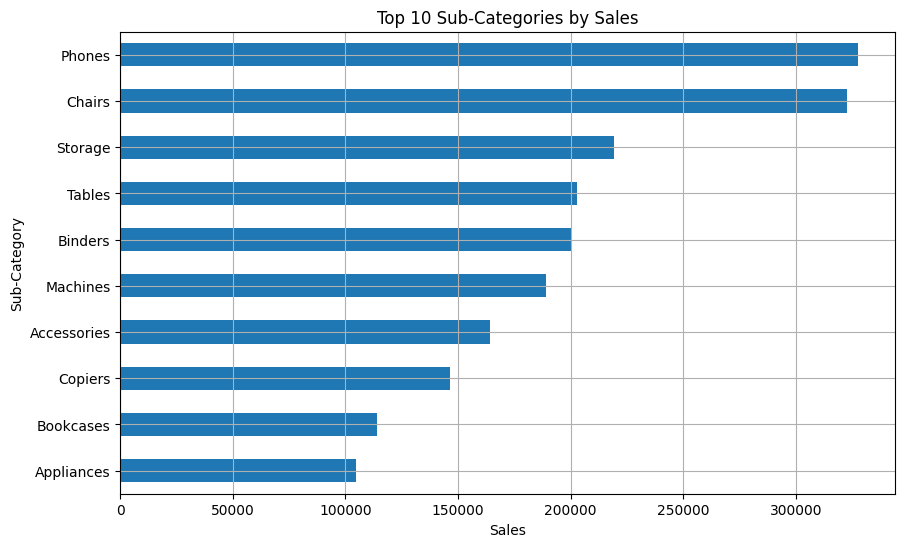

In [22]:
plot_horizontal_bar_chart(top_subcategory_sales, "Top 10 Sub-Categories by Sales", "Sales", "Sub-Category", "../reports/figures/top_10_subcategory_sales.png")

## Top 10 City theo doanh số

In [23]:
top_city_sales = clean_df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
top_city_sales

City
New York City    252462.5470
Los Angeles      173420.1810
Seattle          116106.3220
San Francisco    109041.1200
Philadelphia     108841.7490
Houston           63956.1428
Chicago           47820.1330
San Diego         47521.0290
Jacksonville      44713.1830
Detroit           42446.9440
Name: Sales, dtype: float64

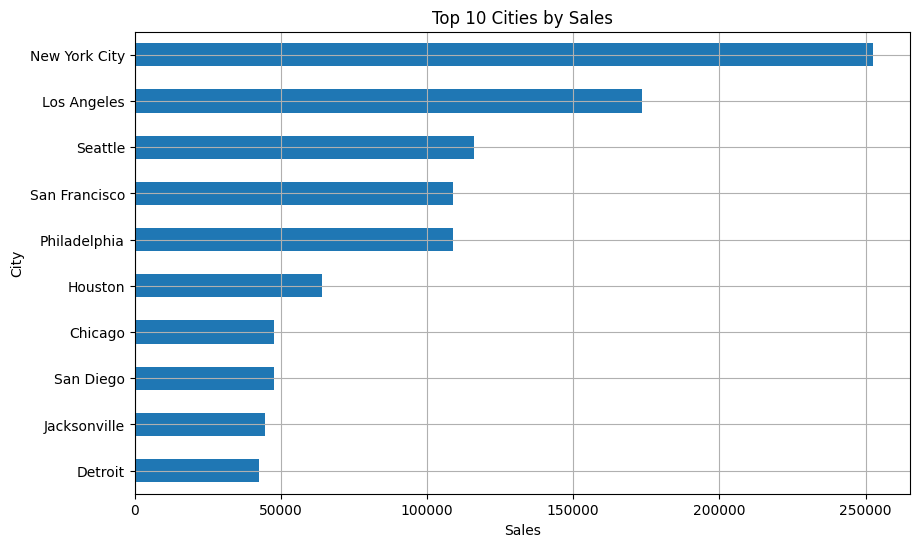

In [24]:
plot_horizontal_bar_chart(top_city_sales, "Top 10 Cities by Sales", "Sales", "City", "../reports/figures/top_10_city_sales.png")

## Top 10 State theo doanh số

In [25]:
top_state_sales = clean_df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
top_state_sales

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

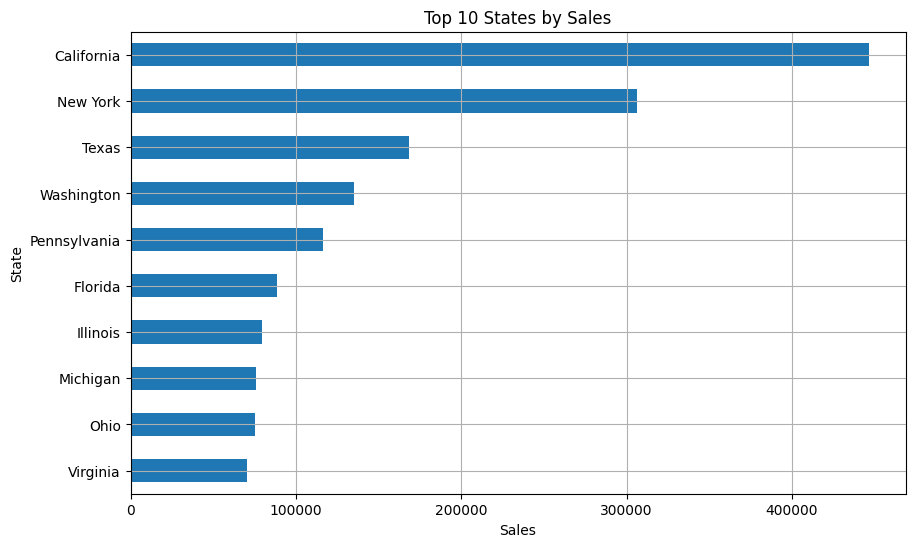

In [26]:
plot_horizontal_bar_chart(top_state_sales, "Top 10 States by Sales", "Sales", "State", "../reports/figures/top_10_state_sales.png")

## Thời gian giao hàng trung bình theo Ship Mode

In [27]:
delivery_by_ship_mode = clean_df.groupby("Ship Mode")["Delivery Days"].mean().sort_values()
delivery_by_ship_mode

Ship Mode
Same Day          0.044610
First Class       2.179214
Second Class      3.249211
Standard Class    5.008363
Name: Delivery Days, dtype: float64

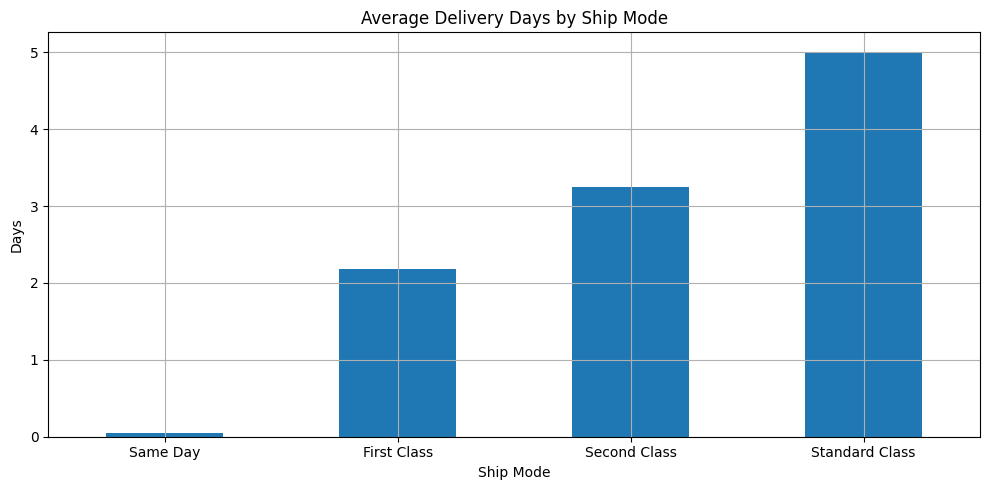

In [28]:
plot_bar_chart(delivery_by_ship_mode, "Average Delivery Days by Ship Mode", "Ship Mode", "Days", "../reports/figures/delivery_days_by_ship_mode.png")